In [4]:
from understatapi import UnderstatClient


with UnderstatClient() as understat:
    teams = understat.league(league="EPL").get_team_data(season="2025")
print(type(teams), len(teams))
first_key = list(teams.keys())[0]
print(teams[first_key].keys())
print(teams[first_key]["history"][0])


<class 'dict'> 20
dict_keys(['id', 'title', 'history'])
{'h_a': 'h', 'xG': 0.318601, 'xGA': 1.40098, 'npxG': 0.318601, 'npxGA': 1.40098, 'ppda': {'att': 227, 'def': 12}, 'ppda_allowed': {'att': 146, 'def': 24}, 'deep': 2, 'deep_allowed': 6, 'scored': 0, 'missed': 0, 'xpts': 0.42579999999999996, 'result': 'd', 'date': '2025-08-16 11:30:00', 'wins': 0, 'draws': 1, 'loses': 0, 'pts': 1, 'npxGD': -1.082379}


In [13]:
import pandas as pd
rows=[]

for team_id, team_info in teams.items():
    team_name = team_info['title']

    for match in team_info['history']:
        row = {"team": team_name, **match}
        rows.append(row)
df = pd.DataFrame(rows)

print(df.shape)
print(df.head())
print(df["team"].value_counts())
    

(760, 20)
          team h_a        xG       xGA      npxG     npxGA  \
0  Aston Villa   h  0.318601  1.400980  0.318601  1.400980   
1  Aston Villa   a  0.976852  1.129640  0.976852  1.129640   
2  Aston Villa   h  1.205860  2.597130  1.205860  1.835960   
3  Aston Villa   a  0.354327  1.892700  0.354327  1.892700   
4  Aston Villa   a  0.939354  0.938312  0.939354  0.938312   

                      ppda             ppda_allowed  deep  deep_allowed  \
0  {'att': 227, 'def': 12}  {'att': 146, 'def': 24}     2             6   
1   {'att': 92, 'def': 17}  {'att': 302, 'def': 28}    14             2   
2  {'att': 222, 'def': 21}  {'att': 288, 'def': 15}     6             5   
3  {'att': 159, 'def': 19}  {'att': 191, 'def': 27}     3            10   
4  {'att': 112, 'def': 16}  {'att': 227, 'def': 23}    16             4   

   scored  missed    xpts result                 date  wins  draws  loses  \
0       0       0  0.4258      d  2025-08-16 11:30:00     0      1      0   
1       0   

In [14]:
df.to_csv("epl_2025_team_matches.csv", index=False)

In [17]:
df.dtypes

team                str
h_a                 str
xG              float64
xGA             float64
npxG            float64
npxGA           float64
ppda             object
ppda_allowed     object
deep              int64
deep_allowed      int64
scored            int64
missed            int64
xpts            float64
result              str
date                str
wins              int64
draws             int64
loses             int64
pts               int64
npxGD           float64
dtype: object

In [21]:
luck = df.groupby('team')[["pts","xpts"]].sum()

luck["luck"] = luck["pts"]-luck["xpts"]
luck = luck.sort_values("luck", ascending = False)

print(luck)

                         pts     xpts     luck
team                                          
Aston Villa               65  51.0701  13.9299
Sunderland                54  42.0286  11.9714
Fulham                    52  45.0773   6.9227
Manchester United         71  64.4460   6.5540
Arsenal                   85  79.8749   5.1251
Manchester City           78  73.9454   4.0546
Everton                   49  46.1733   2.8267
Nottingham Forest         44  42.2415   1.7585
Liverpool                 60  61.5376  -1.5376
Burnley                   22  24.3057  -2.3057
Brighton                  53  55.3489  -2.3489
Bournemouth               57  60.3276  -3.3276
Brentford                 53  57.2441  -4.2441
West Ham                  39  43.4899  -4.4899
Newcastle United          49  54.8333  -5.8333
Chelsea                   52  58.8512  -6.8512
Tottenham                 41  49.2538  -8.2538
Crystal Palace            45  53.8765  -8.8765
Leeds                     47  56.4957  -9.4957
Wolverhampton

In [22]:
print(luck["pts"].sum(), luck["xpts"].sum(), luck["luck"].sum())

1036 1055.8598 -19.859799999999982


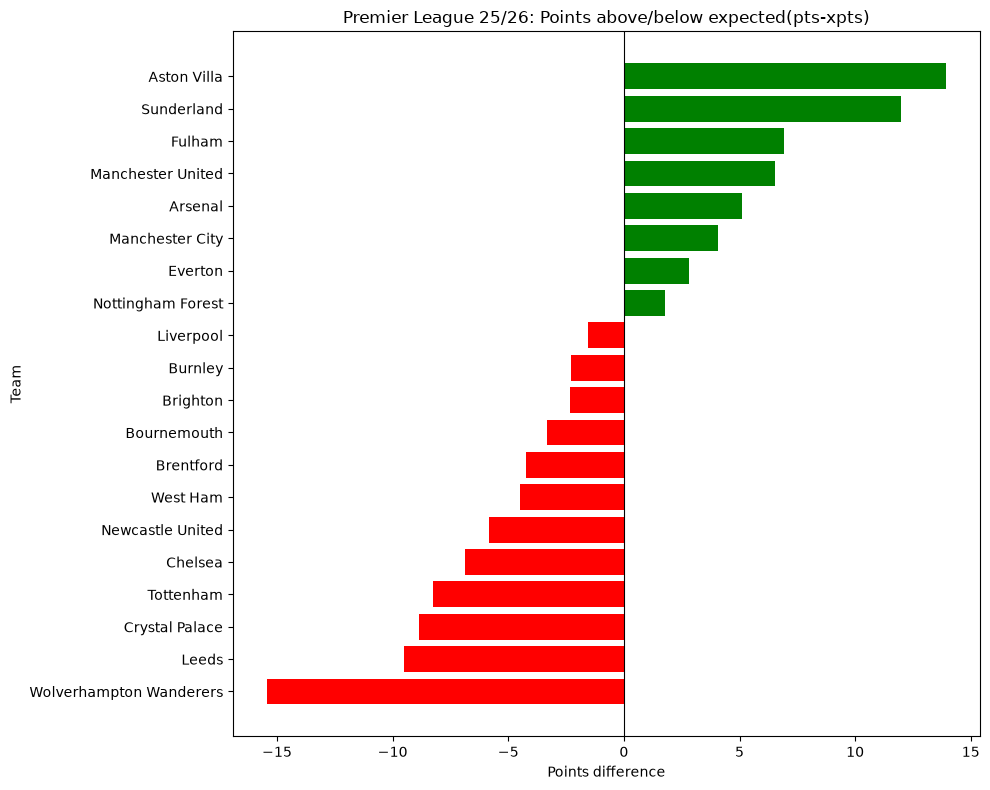

In [24]:
import matplotlib.pyplot as plt

plot_df = luck.sort_values("luck")
colors  = ["green" if x > 0 else "red" for x in plot_df["luck"]]

fig, ax = plt.subplots(figsize=(10,8))
ax.barh(plot_df.index, plot_df["luck"], color = colors)

ax.axvline(0,color="black",linewidth=0.8)
ax.set_title("Premier League 25/26: Points above/below expected(pts-xpts)")
ax.set_xlabel("Points difference")
ax.set_ylabel("Team")
plt.tight_layout()
plt.savefig("luck_25_26.png",dpi=150)
plt.show()

